# Bike-lane surface classification — GMA pipeline

This notebook is a cell-by-cell version of `GMA_lib.py`. Every function from the library sits in its own cell,
**unchanged**, followed by a cell that runs it on the recordings in `InputData/` so you can see what it produces.

| Step | What happens | In → Out |
|---|---|---|
| **0. Ingestion & split** | Unzip sessions, merge the 9 sensor axes + metadata + annotation flag into one dataframe, check annotation coverage, split train/test | folder path → CSV / dataframe |
| **1. Preprocessing** | Trim the start/end of every session, fill missing values, band-pass filter | dataframe → dataframe |
| **2. Windowing & EDA** | Cut each session into fixed-length overlapping windows; look at the signals | dataframe → (n_windows, dataframe) |
| **3. Feature extraction & engineering** | Per-window statistics on orientation-independent signals, correlation filter, PCA | windowed dataframe → feature / PC dataframe |

**Data layout.** Each file in `InputData/` is one Sensor Logger recording (`YYYY-MM-DD_HH-MM-SS.zip`) with
`Accelerometer.csv`, `Gyroscope.csv`, `Gravity.csv`, `Metadata.csv`, `Annotation.csv` (+ uncalibrated files that are ignored).
One zip = one session.

## Imports

All import statements from `GMA_lib.py` collected in one place (duplicates removed). `zipfile` is the only addition — it is
needed by the unzip helper in Step 0 because the raw sessions are stored as zip files.

In [1]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import butter, filtfilt
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

### Paths

- `ZIP_PATH` – folder with the raw `.zip` recordings.
- `DATASET_PATH` – folder the zips get extracted into (one sub-folder per session). This is the `input_path` the library functions expect.
- `OUTPUT_PATH` – where CSV outputs are written (`data_ingestion` / `build_session_dataset` default to `DATASET_PATH.parent / "OutputData"`).

In [2]:
ZIP_PATH = Path("InputData")
DATASET_PATH = Path("InputData_extracted")
OUTPUT_PATH = Path("OutputData")

---
# Step 0 — Ingestion & split
**In:** path to the session folder  **Out:** CSV (`sessions_dataset.csv`) + dataframe

Goal: build **one dataframe** containing, for every sample,
`seconds_elapsed`, the **9 sensor axes** (accelerometer x/y/z, gyroscope x/y/z, gravity x/y/z), `annotation` (bool),
`id` (row id), `id_device`, `type_device` and `session`. The number of sessions must equal the number of zip files.

### Constants: which files are read

- `ALLOWED_FILES` – the only CSVs `data_ingestion` will pick up from a session folder (the *Uncalibrated* files are skipped).
- `SENSOR_FILES` – maps each sensor CSV to the column prefix used in the merged dataset (`accel_`, `gyro_`, `gravity_`).

In [3]:
ALLOWED_FILES = {
    "Accelerometer.csv",
    "Gyroscope.csv",
    "Gravity.csv",
    "Metadata.csv",
    "Annotation.csv",
}

SENSOR_FILES = {
    "Accelerometer.csv": "accel",
    "Gyroscope.csv": "gyro",
    "Gravity.csv": "gravity",
}

### Helper (added for the notebook): unzip the sessions

*Not part of `GMA_lib.py`.* The library functions iterate over **sub-folders** of `input_path`, but the recordings are
stored as zip files. This cell extracts every zip into `DATASET_PATH/<zip name>/` so each recording becomes one session
folder. Already-extracted sessions are skipped, so re-running is cheap.

In [4]:
def unzip_sessions(zip_dir, out_dir):
    zip_dir, out_dir = Path(zip_dir), Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    zips = sorted(zip_dir.glob("*.zip"))
    for z in zips:
        target = out_dir / z.stem
        if not target.exists():
            with zipfile.ZipFile(z) as zf:
                zf.extractall(target)
    print(f"{len(zips)} zip files -> {len(list(out_dir.iterdir()))} session folders in {out_dir}")
    return len(zips)


n_zip_files = unzip_sessions(ZIP_PATH, DATASET_PATH)

28 zip files -> 28 session folders in InputData_extracted


### `_read_csv_file(path)`

Safe CSV reader used by every loader below.
- Returns `None` if the file does not exist, is 0 bytes, is empty after parsing, or raises `EmptyDataError`.
- Otherwise returns the file as a DataFrame.

This is what lets a session with a missing or empty `Annotation.csv` / `Gyroscope.csv` be handled without crashing.

In [5]:
def _read_csv_file(path):
    """
    Reads a CSV file from disk into a DataFrame.

    :param path: Path object pointing to the file.
    :return: DataFrame or None if missing, empty or unreadable.
    """
    if not path.is_file() or path.stat().st_size == 0:
        return None
    try:
        df = pd.read_csv(path)
        return df if not df.empty else None
    except (pd.errors.EmptyDataError, FileNotFoundError):
        return None

In [6]:
# quick check on one session
example_session_dir = sorted(p for p in DATASET_PATH.iterdir() if p.is_dir())[0]
_read_csv_file(example_session_dir / "Accelerometer.csv").head()

,time,seconds_elapsed,z,y,x
0,1788772937715854000,0.082854,-0.861441,-0.036312,-1.647367
1,1788772937725823200,0.092823,-0.211392,-0.166431,-1.228133
2,1788772937735792000,0.102792,0.994809,-0.348755,-1.030725
3,1788772937745760300,0.112760,0.951599,-0.296718,-1.056755
4,1788772937755729200,0.122729,1.521363,-0.326776,-1.029693


### `data_ingestion(input_path, output_path=None, save_csv=True)`

**Per-sensor stacking** (one table per file type, not merged across sensors).
1. Loops over every session folder (sorted by name = chronological).
2. Reads each file in `ALLOWED_FILES`, drops any existing `recording_id` column and inserts the session folder name as `recording_id`.
3. Concatenates all sessions per file type and drops duplicate rows.
4. Optionally writes `Accelerometer.csv`, `Gyroscope.csv`, … to `OutputData/`.

**Returns** a dict `{file_stem: DataFrame}`. Useful for inspecting raw sensor tables; the model pipeline uses `build_session_dataset` instead.

In [7]:
def data_ingestion(input_path, output_path=None, save_csv=True):
    """
    Concatenates matching CSV file types across all session directories into single DataFrames.

    :param input_path: Path to the root input directory.
    :param output_path: Optional path for saving merged files.
    :param save_csv: Boolean indicating whether to write CSVs to disk.
    :return: Dict of DataFrames per sensor/file type.
    """
    input_path = Path(input_path)
    output_path = Path(output_path) if output_path else input_path.parent / "OutputData"

    collected = {}

    for session_dir in sorted(p for p in input_path.iterdir() if p.is_dir()):
        for csv_path in session_dir.glob("*.csv"):
            if csv_path.name not in ALLOWED_FILES:
                continue

            df = _read_csv_file(csv_path)
            if df is not None:
                # Optimized removal and insertion of recording_id
                df = df.drop(columns=["recording_id"], errors="ignore")
                df.insert(0, "recording_id", session_dir.name)

                collected.setdefault(csv_path.stem, []).append(df)

    if not collected:
        print(f"No valid session data found in {input_path}")
        return {}

    dataframes = {
        key: pd.concat(dfs, ignore_index=True).drop_duplicates() 
        for key, dfs in collected.items()
    }

    if save_csv:
        output_path.mkdir(parents=True, exist_ok=True)
        for key, df in dataframes.items():
            df.to_csv(output_path / f"{key}.csv", index=False)
            print(f"Saved: {key}.csv ({len(df)} rows)")

    return dataframes

In [8]:
raw_tables = data_ingestion(input_path=DATASET_PATH, save_csv=True)
{k: v.shape for k, v in raw_tables.items()}

Saved: Metadata.csv (28 rows)
Saved: Gyroscope.csv (618015 rows)
Saved: Gravity.csv (618015 rows)
Saved: Accelerometer.csv (618015 rows)
Saved: Annotation.csv (69 rows)


{'Metadata': (28, 13), 'Gyroscope': (618015, 6), 'Gravity': (618015, 6), 'Accelerometer': (618015, 6), 'Annotation': (69, 5)}

In [9]:
raw_tables["Accelerometer"].head()

,recording_id,time,seconds_elapsed,z,y,x
0,2026-09-07_09-22-17,1788772937715854000,0.082854,-0.861441,-0.036312,-1.647367
1,2026-09-07_09-22-17,1788772937725823200,0.092823,-0.211392,-0.166431,-1.228133
2,2026-09-07_09-22-17,1788772937735792000,0.102792,0.994809,-0.348755,-1.030725
3,2026-09-07_09-22-17,1788772937745760300,0.112760,0.951599,-0.296718,-1.056755
4,2026-09-07_09-22-17,1788772937755729200,0.122729,1.521363,-0.326776,-1.029693


### `build_session_dataset(input_path, output_path=None, save_csv=True)` — the main Step 0 dataframe

For every session folder (numbered `1…N` in sorted order):
1. **Load sensors** – reads Accelerometer / Gyroscope / Gravity, strips column names, drops `recording_id` and the absolute `time`
   column, renames `x,y,z` → `accel_x`, `gyro_y`, `gravity_z`, …, de-duplicates and sorts on `seconds_elapsed`.
2. **Skip** the session if there is no accelerometer file (it is the reference timeline).
3. **Time-align** gyroscope and gravity onto the accelerometer timestamps with `pd.merge_asof(direction="nearest")` — the
   sensors are not sampled at exactly the same instants, so each accelerometer sample gets the closest gyro/gravity sample.
4. **Session attributes** from `Metadata.csv` (`device name` → `type_device`, `device id` → `id_device`) and
   `annotation = True` if `Annotation.csv` exists and is non-empty.
5. Concatenates all sessions and adds a global running `id`.

**Output columns:** `id, session, seconds_elapsed, accel_x/y/z, gyro_x/y/z, gravity_x/y/z, type_device, id_device, annotation`
→ saved as `OutputData/sessions_dataset.csv`.

In [10]:
def build_session_dataset(input_path, output_path=None, save_csv=True):
    """
    Merges sensor axes (Accelerometer, Gyroscope, Gravity), metadata, and annotations.

    :param input_path: Path to the root input directory.
    :param output_path: Optional path for saving the final dataset.
    :param save_csv: Boolean indicating whether to write CSV to disk.
    :return: Merged dataset DataFrame.
    """
    input_path = Path(input_path)
    output_path = Path(output_path) if output_path else input_path.parent / "OutputData"

    sessions = []
    session_dirs = sorted(p for p in input_path.iterdir() if p.is_dir())

    for session_num, session_dir in enumerate(session_dirs, start=1):
        sensor_dfs = {}

        # 1. Load and process sensor files
        for fname, prefix in SENSOR_FILES.items():
            df = _read_csv_file(session_dir / fname)
            if df is not None:
                df.columns = df.columns.str.strip()
                df = df.drop(columns=["recording_id", "time"], errors="ignore")

                # Rename sensor channels
                rename_map = {
                    c: f"{prefix}_{c}" for c in df.columns if c != "seconds_elapsed"
                }
                df = df.rename(columns=rename_map)

                # Deduplicate and sort timestamps
                df = df.drop_duplicates(subset=["seconds_elapsed"]).sort_values("seconds_elapsed")
                sensor_dfs[prefix] = df

        # Accelerometer is mandatory as base reference
        if "accel" not in sensor_dfs:
            continue

        # 2. Sequential merge using Accelerometer as main timeline
        merged = sensor_dfs["accel"]

        for prefix in ["gyro", "gravity"]:
            if prefix in sensor_dfs:
                merged = pd.merge_asof(
                    merged,
                    sensor_dfs[prefix],
                    on="seconds_elapsed",
                    direction="nearest",
                )

        # 3. Metadata and Annotation extraction
        meta_df = _read_csv_file(session_dir / "Metadata.csv")
        type_device = meta_df.iloc[0].get("device name") if meta_df is not None else None
        id_device = meta_df.iloc[0].get("device id") if meta_df is not None else None

        annot_file = session_dir / "Annotation.csv"
        has_annotation = annot_file.is_file() and annot_file.stat().st_size > 0

        # 4. Attach session attributes
        merged["type_device"] = type_device
        merged["id_device"] = id_device
        merged["annotation"] = has_annotation
        merged.insert(0, "session", session_num)

        sessions.append(merged)

    if not sessions:
        return pd.DataFrame()

    # Concatenate and assign unique sequential ID fast
    dataset = pd.concat(sessions, ignore_index=True)
    dataset = dataset.reset_index().rename(columns={"index": "id"})

    if save_csv:
        output_path.mkdir(parents=True, exist_ok=True)
        dataset.to_csv(output_path / "sessions_dataset.csv", index=False)
        print(
            f"Saved: sessions_dataset.csv ({len(dataset)} rows, {len(sessions)} sessions merged)"
        )

    return dataset

In [11]:
dataset_df = build_session_dataset(input_path=DATASET_PATH, save_csv=True)
dataset_df.head()

Saved: sessions_dataset.csv (618015 rows, 28 sessions merged)


,id,session,seconds_elapsed,accel_z,accel_y,accel_x,gyro_z,gyro_y,gyro_x,gravity_z,gravity_y,gravity_x,type_device,id_device,annotation
0,0,1,0.082854,-0.861441,-0.036312,-1.647367,-0.416015,0.119823,0.698398,-7.970919,-5.310090,2.106605,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
1,1,1,0.092823,-0.211392,-0.166431,-1.228133,-0.399588,0.085356,0.782289,-7.929193,-5.360584,2.135984,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
2,2,1,0.102792,0.994809,-0.348755,-1.030725,-0.408360,0.065377,0.802358,-7.884873,-5.414837,2.163032,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
3,3,1,0.112760,0.951599,-0.296718,-1.056755,-0.427181,0.016619,0.743897,-7.841663,-5.466874,2.189063,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
4,4,1,0.122729,1.521363,-0.326776,-1.029693,-0.472437,-0.098900,0.606179,-7.805394,-5.509988,2.210484,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False


#### Sanity check: one session per zip file

In [12]:
n_sessions = dataset_df["session"].nunique()
print(f"zip files: {n_zip_files} | sessions in dataset: {n_sessions} | match: {n_zip_files == n_sessions}")
print(f"shape: {dataset_df.shape}")

session_summary = dataset_df.groupby("session").agg(
    rows=("id", "size"),
    duration_s=("seconds_elapsed", "max"),
    annotation=("annotation", "first"),
    type_device=("type_device", "first"),
)
session_summary.insert(0, "folder", sorted(p.name for p in DATASET_PATH.iterdir() if p.is_dir()))
session_summary

zip files: 28 | sessions in dataset: 28 | match: True
shape: (618015, 15)


,folder,rows,duration_s,annotation,type_device
session,,,,,
1,2026-09-07_09-22-17,7466,74.507208,False,iPhone 16 Pro
2,2026-09-07_16-40-47,87027,867.701849,False,iPhone 16 Pro
3,2026-09-07_16-58-41,77503,772.733097,False,iPhone 16 Pro
4,2026-09-08_06-32-54,33489,333.879605,False,iPhone 16 Pro
5,2026-09-09_07-58-02,24210,241.417763,False,iPhone 16 Pro
6,2026-09-09_12-31-36,551,5.553402,False,iPhone 16 Pro
7,2026-09-10_16-47-43,3982,40.037814,False,iPhone 17
8,2026-09-10_16-49-41,5285,57.761704,False,iPhone 17
9,2026-09-10_16-51-29,5547,82.177511,False,iPhone 17


### `check_annotation_percentage(df, plot=True)`

Answers *"how much of the recorded time is labelled?"*
- Groups by `session`, takes the session length (`max seconds_elapsed`) and whether it is annotated.
- Sums the minutes of annotated vs non-annotated sessions and prints the coverage percentage.
- Draws a pie chart of annotated vs not-annotated recording time.

**Returns** a dict with session counts, minutes and `annotated_pct`.

In [13]:
def check_annotation_percentage(df, plot=True):
    """
    Checks annotation coverage across all recorded sessions.

    :param df: pandas.DataFrame (must contain 'session', 'annotation', 'seconds_elapsed')
    :param plot: Boolean flag to visualize results with matplotlib.
    :return: Summary metrics dict.
    """
    if df.empty:
        return {}

    # Vectorized fast aggregation
    stats = df.groupby("session").agg(
        max_seconds=("seconds_elapsed", "max"),
        has_annotation=("annotation", "any"),
    )
    stats["minutes"] = stats["max_seconds"] / 60.0

    annotated = stats[stats["has_annotation"]]
    not_annotated = stats[~stats["has_annotation"]]

    ann_min = annotated["minutes"].sum()
    not_ann_min = not_annotated["minutes"].sum()
    total_min = ann_min + not_ann_min

    result = {
        "annotated_sessions": len(annotated),
        "not_annotated_sessions": len(not_annotated),
        "annotated_minutes": round(ann_min, 2),
        "not_annotated_minutes": round(not_ann_min, 2),
        "total_minutes": round(total_min, 2),
        "annotated_pct": round(ann_min / total_min * 100, 2) if total_min > 0 else 0.0,
    }

    print(
        f"Annotated: {result['annotated_sessions']} sess. ({result['annotated_minutes']} min) | "
        f"Not annotated: {result['not_annotated_sessions']} sess. ({result['not_annotated_minutes']} min) | "
        f"Coverage: {result['annotated_pct']}% of total ({result['total_minutes']} min)"
    )

    if plot and total_min > 0:
        labels = ["Annotated", "Not Annotated"]
        sizes = [result["annotated_minutes"], result["not_annotated_minutes"]]
        colors = ["#075e2b", "#972518"]
        explode = (0.05, 0)

        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            explode=explode,
            labels=labels,
            colors=colors,
            autopct="%1.1f%%",
            startangle=140,
            wedgeprops={"edgecolor": "black"},
        )
        plt.title(
            f"Annotated vs Not Annotated Recording Time\nTotal: {result['total_minutes']} min"
        )
        plt.tight_layout()
        plt.show()

    return result

Annotated: 8 sess. (25.35 min) | Not annotated: 20 sess. (80.97 min) | Coverage: 23.84% of total (106.32 min)


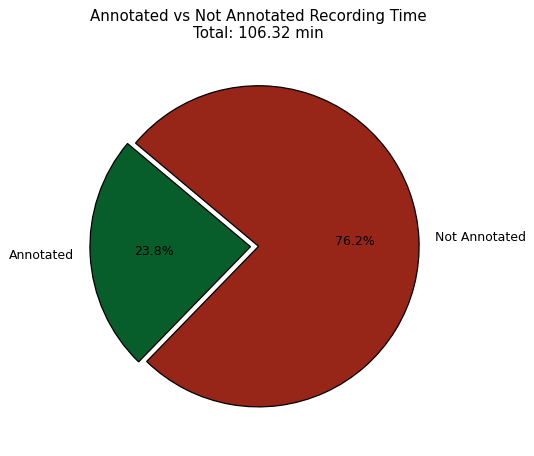

{'annotated_sessions': 8, 'not_annotated_sessions': 20, 'annotated_minutes': np.float64(25.35), 'not_annotated_minutes': np.float64(80.97), 'total_minutes': np.float64(106.32), 'annotated_pct': np.float64(23.84)}

In [14]:
annotation_summary = check_annotation_percentage(dataset_df, plot=True)
annotation_summary

### `train_test_split_by_annotation(df)`

Session-level split (no session is ever split across the two sets, so there is no leakage between neighbouring samples):
- **Train** = all sessions **without** annotations (`annotation == False`)
- **Test** = all sessions **with** annotations (`annotation == True`) — the labelled rides are held out for evaluation.

Prints the number of sessions and rows in each set and returns `(train_df, test_df)`.

In [15]:
def train_test_split_by_annotation(df):
    """
    Splits the dataset into train and test sets based on annotation presence.

    - Train: All sessions without annotations (annotation == False)
    - Test : All sessions with annotations (annotation == True)
    """
    if df.empty:
        print("Warning: Input DataFrame is empty.")
        return pd.DataFrame(), pd.DataFrame()

    train_df = df[~df["annotation"]]
    test_df = df[df["annotation"]]

    train_sessions = train_df["session"].nunique()
    test_sessions = test_df["session"].nunique()

    print(
        f"Split Summary:\n"
        f" - Train set (Not Annotated): {train_sessions} sessions, {len(train_df)} rows\n"
        f" - Test set  (Annotated)    : {test_sessions} sessions, {len(test_df)} rows"
    )

    return train_df, test_df

In [16]:
train_df, test_df = train_test_split_by_annotation(dataset_df)
test_df.head()

Split Summary:
 - Train set (Not Annotated): 20 sessions, 467868 rows
 - Test set  (Annotated)    : 8 sessions, 150147 rows


,id,session,seconds_elapsed,accel_z,accel_y,accel_x,gyro_z,gyro_y,gyro_x,gravity_z,gravity_y,gravity_x,type_device,id_device,annotation
304395,304395,12,0.062491,-0.018321,0.034339,-0.193665,0.054855,-0.080011,0.128090,-8.730541,-4.454933,0.318762,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,True
304396,304396,12,0.072458,0.072950,-0.039855,-0.237276,0.041281,-0.053606,0.134476,-8.724846,-4.466630,0.310898,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,True
304397,304397,12,0.082425,0.052063,-0.043924,-0.221331,0.031752,-0.034837,0.123690,-8.719222,-4.477975,0.305427,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,True
304398,304398,12,0.092394,-0.018893,0.015186,-0.177367,0.032066,-0.012994,0.115910,-8.713958,-4.488453,0.301866,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,True
304399,304399,12,0.102362,0.101855,0.108021,-0.065828,0.048669,-0.012936,0.097345,-8.709159,-4.497939,0.299113,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,True


---
# Step 1 — Preprocessing
**In:** the Step 0 dataframe (or `sessions_dataset.csv`)  **Out:** cleaned, filtered dataframe

Every function here works **per session** (`groupby("session")`), so trimming, interpolation and filtering never mix
samples from two different recordings.

1. Trim *x* seconds from the front and back of each session (removes phone handling at start/stop).
2. Handle missing values.
3. Band-pass filter all sensor channels.

### Preprocessing constants

- `FS = 100.0` Hz – nominal sampling rate. `Metadata.csv` reports `sampleRateMs = 10`, i.e. 100 Hz, so this matches the recordings.
- Column groups for the 9 sensor axes; `ALL_SENSOR_COLS` is the default input for the preprocessing functions.

In [17]:
# ==================================================================
# PREPROCESSING FROM HERE ON OUT(in line w the code above): trimming, missing values, band-pass filter, windowing, EDA
# -- operating on the DataFrame returned by build_session_dataset(), whose
# columns are: id, session, seconds_elapsed, accel_x/y/z, gyro_x/y/z,
# gravity_x/y/z, type_device, id_device, annotation.
#
# Every step below groups by "session" so trimming/filtering/interpolation/
# windowing never blends two different recordings together.
# ==================================================================

FS = 100.0  # nominal sampling rate

ACCEL_COLS = ["accel_x", "accel_y", "accel_z"]
GYRO_COLS = ["gyro_x", "gyro_y", "gyro_z"]
GRAVITY_COLS = ["gravity_x", "gravity_y", "gravity_z"]
ALL_SENSOR_COLS = ACCEL_COLS + GYRO_COLS + GRAVITY_COLS

### `trim_dataframe(df, trim_start_sec=0, trim_end_sec=0, fs=FS, session_col="session")`

**In:** multi-session dataframe, seconds to trim at the front and back of **each** session  **Out:** trimmed dataframe

- Converts seconds to samples (`seconds × fs`).
- Removes the first `start_samples` and last `end_samples` rows of every session.
- Sessions shorter than the total trim are **skipped** with a warning (they would be empty).
- Prints row counts before/after.

In [18]:
def trim_dataframe(df: pd.DataFrame, trim_start_sec: float = 0, trim_end_sec: float = 0,
                    fs: float = FS, session_col: str = "session") -> pd.DataFrame:
    """
    in: dataframe (multi-session), seconds to trim from the front and back
        of EACH session, sampling rate
    out: trimmed dataframe (all sessions concatenated back together)
    """
    start_samples = int(trim_start_sec * fs)
    end_samples = int(trim_end_sec * fs)

    trimmed_sessions = []
    for session_id, group in df.groupby(session_col, sort=False):
        group = group.reset_index(drop=True)
        if start_samples + end_samples >= len(group):
            print(f"  WARNING: session {session_id} too short to trim ({len(group)} rows) — skipping.")
            continue
        trimmed = group.iloc[start_samples:-end_samples] if end_samples > 0 else group.iloc[start_samples:]
        trimmed_sessions.append(trimmed)

    result = pd.concat(trimmed_sessions, ignore_index=True)
    print(f"Rows before trimming: {len(df)} -> after: {len(result)}")
    return result

In [19]:
df_trimmed = trim_dataframe(dataset_df, trim_start_sec=3.0, trim_end_sec=3.0, fs=FS)
print(f"sessions before: {dataset_df['session'].nunique()} -> after: {df_trimmed['session'].nunique()}")
df_trimmed.head()

Rows before trimming: 618015 -> after: 601264
sessions before: 28 -> after: 27


,id,session,seconds_elapsed,accel_z,accel_y,accel_x,gyro_z,gyro_y,gyro_x,gravity_z,gravity_y,gravity_x,type_device,id_device,annotation
0,300,1,3.073480,0.775033,1.082694,0.720464,0.471889,-0.054443,0.671071,-7.506929,-6.280655,-0.608086,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
1,301,1,3.083448,0.786267,1.088602,0.697649,0.482491,-0.108805,0.675867,-7.463994,-6.328014,-0.644528,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
2,302,1,3.093418,0.767778,1.046364,0.500680,0.479918,-0.144180,0.679592,-7.420067,-6.375259,-0.684884,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
3,303,1,3.103386,0.752696,0.912149,0.239031,0.454164,-0.134114,0.669971,-7.375806,-6.421956,-0.725503,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False
4,304,1,3.113355,0.830551,0.719537,0.042853,0.421597,-0.094099,0.631099,-7.332904,-6.466668,-0.762310,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False


### `handle_missing_values(df, columns=ALL_SENSOR_COLS, session_col="session", strategy="interpolate")`

Fills gaps in the sensor columns, per session:
- `"interpolate"` (default) – linear interpolation, also filling leading/trailing NaNs (`limit_direction="both"`).
- `"drop"` – drop rows that have any NaN in `columns`.
- `"ffill"` – forward-fill then back-fill.

Prints the total number of missing values before and after. Gaps mostly come from a sensor file missing or starting
slightly later than the accelerometer.

In [20]:
def handle_missing_values(df: pd.DataFrame, columns: list = ALL_SENSOR_COLS,
                           session_col: str = "session", strategy: str = "interpolate") -> pd.DataFrame:
    """
    in: dataframe, columns to check/fill, strategy ("interpolate"/"drop"/"ffill")
    out: dataframe with missing values handled (per session, so interpolation
         never pulls in a sample from a different recording)
    """
    total_missing_before = df[columns].isna().sum().sum()

    filled_sessions = []
    for session_id, group in df.groupby(session_col, sort=False):
        group = group.copy()
        if strategy == "interpolate":
            group[columns] = group[columns].interpolate(method="linear", limit_direction="both")
        elif strategy == "drop":
            group = group.dropna(subset=columns)
        elif strategy == "ffill":
            group[columns] = group[columns].ffill().bfill()
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
        filled_sessions.append(group)

    result = pd.concat(filled_sessions, ignore_index=True)
    total_missing_after = result[columns].isna().sum().sum()
    print(f"Missing values: {total_missing_before} -> {total_missing_after} (strategy={strategy})")
    return result

In [21]:
print("Missing values per column before:")
print(df_trimmed[ALL_SENSOR_COLS].isna().sum().to_string())
df_clean = handle_missing_values(df_trimmed)
df_clean[ALL_SENSOR_COLS].describe().T

Missing values per column before:
accel_x      0
accel_y      0
accel_z      0
gyro_x       0
gyro_y       0
gyro_z       0
gravity_x    0
gravity_y    0
gravity_z    0
Missing values: 0 -> 0 (strategy=interpolate)


,count,mean,std,min,25%,50%,75%,max
accel_x,601264.0,-0.002078,1.955986,-49.651146,-0.888760,-0.042452,0.784764,31.192054
accel_y,601264.0,0.210057,1.915360,-53.712245,-0.565026,0.081124,0.901834,70.269178
accel_z,601264.0,-0.035185,2.863860,-106.945911,-0.931067,0.000674,0.889085,70.375341
gyro_x,601264.0,0.004919,0.603967,-17.352814,-0.076224,0.002559,0.088411,13.054178
gyro_y,601264.0,0.006502,0.575165,-18.280499,-0.109311,0.000098,0.112802,8.914800
gyro_z,601264.0,0.003238,0.749785,-7.709402,-0.212617,-0.000808,0.202486,9.757018
gravity_x,601264.0,-1.328320,3.919994,-9.804576,-3.710222,-0.282603,0.205509,9.806507
gravity_y,601264.0,-0.146515,5.060550,-9.142091,-3.038893,-2.663413,4.904975,9.806466
gravity_z,601264.0,-6.059529,4.085483,-9.806407,-9.408293,-8.918696,-1.797069,7.906324


### `apply_bandpass_filter(df, columns=ALL_SENSOR_COLS, low_cutoff=5.0, high_cutoff=30.0, fs=FS, order=4, session_col="session")`

Butterworth band-pass (default **5–30 Hz**, 4th order), applied with `filtfilt` (forward + backward → zero phase shift, so
bumps stay aligned in time).
- **< 5 Hz** removed: gravity/orientation drift, slow body movement, pedalling.
- **> 30 Hz** removed: high-frequency sensor noise. The upper cutoff is capped at 95 % of Nyquist (50 Hz).
- Adds a new `<col>_filt` column for every input column; raw columns are kept.
- Sessions too short for `filtfilt`'s padding are kept unfiltered with a warning.

Note: gravity is also filtered by default, but Step 3 uses the **raw** gravity columns for the vertical projection.

In [22]:
def apply_bandpass_filter(df: pd.DataFrame, columns: list = ALL_SENSOR_COLS,
                           low_cutoff: float = 5.0, high_cutoff: float = 30.0,
                           fs: float = FS, order: int = 4,
                           session_col: str = "session") -> pd.DataFrame:
    """
    in: dataframe, columns to filter (defaults to accel+gyro+gravity,
        matching G.ipynb), band cutoffs, sampling rate
    out: dataframe with added *_filt columns, filtered per session
    """
    nyquist = fs / 2
    low_norm = low_cutoff / nyquist
    high_norm = min(high_cutoff, nyquist * 0.95) / nyquist
    b, a = butter(order, [low_norm, high_norm], btype="band", analog=False)
    padlen = 3 * (max(len(b), len(a)) - 1)

    filtered_sessions = []
    for session_id, group in df.groupby(session_col, sort=False):
        group = group.copy()
        if len(group) <= padlen:
            print(f"  WARNING: session {session_id} too short to filter ({len(group)} rows) — keeping raw.")
            for col in columns:
                group[f"{col}_filt"] = group[col]
        else:
            for col in columns:
                group[f"{col}_filt"] = filtfilt(b, a, group[col].values)
        filtered_sessions.append(group)

    return pd.concat(filtered_sessions, ignore_index=True)

In [23]:
df_filtered = apply_bandpass_filter(df_clean)
df_filtered[["session", "seconds_elapsed"] + [c for c in df_filtered.columns if c.endswith("_filt")]].head()

,session,seconds_elapsed,accel_x_filt,accel_y_filt,accel_z_filt,gyro_x_filt,gyro_y_filt,gyro_z_filt,gravity_x_filt,gravity_y_filt,gravity_z_filt
0,1,3.073480,-0.005005,-0.000433,0.000228,-0.004672,0.005881,0.000241,0.000204,0.000119,-0.000158
1,1,3.083448,0.106145,0.125503,-0.143121,0.050492,-0.064535,0.041467,0.000006,0.007568,-0.008225
2,1,3.093418,0.030353,0.142826,-0.268980,0.108453,-0.110047,0.066306,-0.004597,0.013029,-0.013473
3,1,3.103386,-0.147674,0.088087,-0.368889,0.159630,-0.115537,0.071898,-0.011747,0.015014,-0.014603
4,1,3.113355,-0.194063,0.076407,-0.454702,0.192170,-0.096636,0.067125,-0.017623,0.013128,-0.011783


#### Raw vs filtered (5 s of one session)

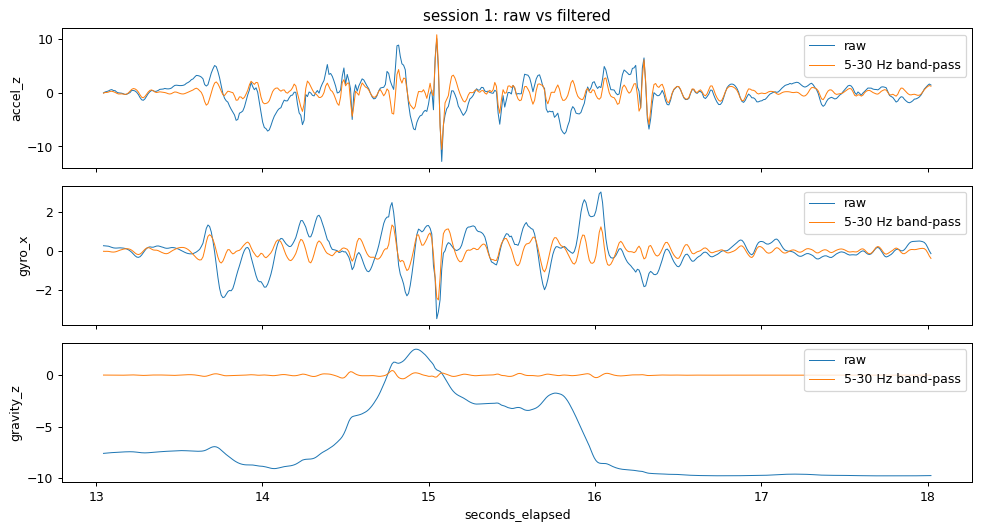

In [24]:
s = df_filtered["session"].iloc[0]
seg = df_filtered[df_filtered["session"] == s].iloc[1000:1500]
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, col in zip(axes, ["accel_z", "gyro_x", "gravity_z"]):
    ax.plot(seg["seconds_elapsed"], seg[col], lw=0.8, label="raw")
    ax.plot(seg["seconds_elapsed"], seg[f"{col}_filt"], lw=0.8, label="5-30 Hz band-pass")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")
axes[0].set_title(f"session {s}: raw vs filtered")
axes[-1].set_xlabel("seconds_elapsed")
plt.tight_layout()
plt.show()

---
# Step 2 — Windowing & EDA
**In:** filtered dataframe, window length, overlap %  **Out:** number of windows, windowed dataframe

### `windowing(df, window_length, overlap_percentage, fs=FS, session_col="session")`

- `window_size = window_length × fs` samples; `step = window_size × (1 − overlap/100)`.
- Slides the window over **each session separately**, so a window never spans two recordings; the tail that does not fill a
  whole window is dropped.
- Each window's rows get a `window_id` that is unique across the whole dataset.

**Returns** `(number_of_windows, long_format_dataframe)`.

Overlap is used at **75 %** here (the agreed cap). The function itself does not enforce a cap, so keep `overlap_percentage ≤ 75` when calling it.
With 1 s windows at 100 Hz: 100 samples per window, a new window every 25 samples.

In [25]:
def windowing(df: pd.DataFrame, window_length: float, overlap_percentage: float,
              fs: float = FS, session_col: str = "session"):
    """
    in: dataframe, window_length (seconds), overlap_percentage (0-100), fs
    out: (number_of_windows, dataframe) -- long-format, with a 'window_id'
         column (unique across the whole multi-session dataset), windowed
         per session so a window never spans two different recordings
    """
    window_size = int(round(window_length * fs))
    step_size = max(1, int(round(window_size * (1 - overlap_percentage / 100))))

    window_frames = []
    window_id = 0
    for session_id, group in df.groupby(session_col, sort=False):
        group = group.reset_index(drop=True)
        n_samples = len(group)
        start = 0
        while start + window_size <= n_samples:
            chunk = group.iloc[start:start + window_size].copy()
            chunk["window_id"] = window_id
            window_frames.append(chunk)
            window_id += 1
            start += step_size

    if not window_frames:
        return 0, pd.DataFrame(columns=list(df.columns) + ["window_id"])

    return window_id, pd.concat(window_frames, ignore_index=True)

In [26]:
WINDOW_LENGTH = 1.0   # seconds
OVERLAP = 75          # %, capped at 75

n_windows, windowed_df = windowing(df_filtered, window_length=WINDOW_LENGTH, overlap_percentage=OVERLAP, fs=FS)
print(f"number of windows: {n_windows}")
print(f"windowed dataframe shape: {windowed_df.shape}")
print(f"samples per window: {windowed_df.groupby('window_id').size().unique()}")
windowed_df.head()

number of windows: 23956
windowed dataframe shape: (2395600, 25)
samples per window: [100]


,id,session,seconds_elapsed,accel_z,accel_y,accel_x,gyro_z,gyro_y,gyro_x,gravity_z,gravity_y,gravity_x,type_device,id_device,annotation,accel_x_filt,accel_y_filt,accel_z_filt,gyro_x_filt,gyro_y_filt,gyro_z_filt,gravity_x_filt,gravity_y_filt,gravity_z_filt,window_id
0,300,1,3.073480,0.775033,1.082694,0.720464,0.471889,-0.054443,0.671071,-7.506929,-6.280655,-0.608086,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False,-0.005005,-0.000433,0.000228,-0.004672,0.005881,0.000241,0.000204,0.000119,-0.000158,0
1,301,1,3.083448,0.786267,1.088602,0.697649,0.482491,-0.108805,0.675867,-7.463994,-6.328014,-0.644528,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False,0.106145,0.125503,-0.143121,0.050492,-0.064535,0.041467,0.000006,0.007568,-0.008225,0
2,302,1,3.093418,0.767778,1.046364,0.500680,0.479918,-0.144180,0.679592,-7.420067,-6.375259,-0.684884,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False,0.030353,0.142826,-0.268980,0.108453,-0.110047,0.066306,-0.004597,0.013029,-0.013473,0
3,303,1,3.103386,0.752696,0.912149,0.239031,0.454164,-0.134114,0.669971,-7.375806,-6.421956,-0.725503,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False,-0.147674,0.088087,-0.368889,0.159630,-0.115537,0.071898,-0.011747,0.015014,-0.014603,0
4,304,1,3.113355,0.830551,0.719537,0.042853,0.421597,-0.094099,0.631099,-7.332904,-6.466668,-0.762310,iPhone 16 Pro,ce2013e9-f8ed-4f6e-93f6-59cb7338ada3,False,-0.194063,0.076407,-0.454702,0.192170,-0.096636,0.067125,-0.017623,0.013128,-0.011783,0


In [27]:
windowed_df.groupby("session")["window_id"].nunique().rename("windows per session").to_frame().T

session,1,2,3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
windows per session,271,3454,3073,1312,941,132,184,194,95,2223,37,885,849,521,585,840,1237,1299,419,540,1180,428,679,220,1001,512,845


### `eda(df, columns=ALL_SENSOR_COLS, time_col="seconds_elapsed", session_col="session")`

Quick exploratory look:
- `describe()` summary statistics and missing-value count per column.
- Number of sessions and rows per session.
- Time-series plot of every column for the **first session** as an example.
- Correlation heat-map of the columns across all sessions combined.

Run twice below: once on the raw 9 axes, once on the band-pass filtered axes.

In [28]:
def eda(df: pd.DataFrame, columns: list = ALL_SENSOR_COLS,
        time_col: str = "seconds_elapsed", session_col: str = "session"):
    """
    in: dataframe, columns to summarize
    out: none (prints summary stats + missing-value counts; plots one
         example session's time series per column, plus a correlation
         heatmap across all sessions combined)
    """
    print(df[columns].describe())
    print("\nMissing values per column:")
    print(df[columns].isna().sum())
    print(f"\nSessions: {df[session_col].nunique()}")
    print(f"Rows per session:\n{df.groupby(session_col).size()}")

    example_session = df[session_col].iloc[0]
    example_df = df[df[session_col] == example_session]

    fig, axes = plt.subplots(len(columns), 1, figsize=(10, 2.0 * len(columns)), sharex=True)
    for ax, col in zip(axes, columns):
        ax.plot(example_df[time_col], example_df[col], linewidth=0.5)
        ax.set_ylabel(col)
    axes[0].set_title(f"session {example_session} (example)")
    axes[-1].set_xlabel(time_col)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    corr = df[columns].corr()
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns))); ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=90); ax.set_yticklabels(columns)
    fig.colorbar(im)
    ax.set_title("correlation matrix (all sessions combined)")
    plt.tight_layout()
    plt.show()

             accel_x        accel_y        accel_z         gyro_x         gyro_y         gyro_z      gravity_x      gravity_y      gravity_z
count  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000
mean       -0.002078       0.210057      -0.035185       0.004919       0.006502       0.003238      -1.328320      -0.146515      -6.059529
std         1.955986       1.915360       2.863860       0.603967       0.575165       0.749785       3.919994       5.060550       4.085483
min       -49.651146     -53.712245    -106.945911     -17.352814     -18.280499      -7.709402      -9.804576      -9.142091      -9.806407
25%        -0.888760      -0.565026      -0.931067      -0.076224      -0.109311      -0.212617      -3.710222      -3.038893      -9.408293
50%        -0.042452       0.081124       0.000674       0.002559       0.000098      -0.000808      -0.282603      -2.663413      -8.918696
75%         0

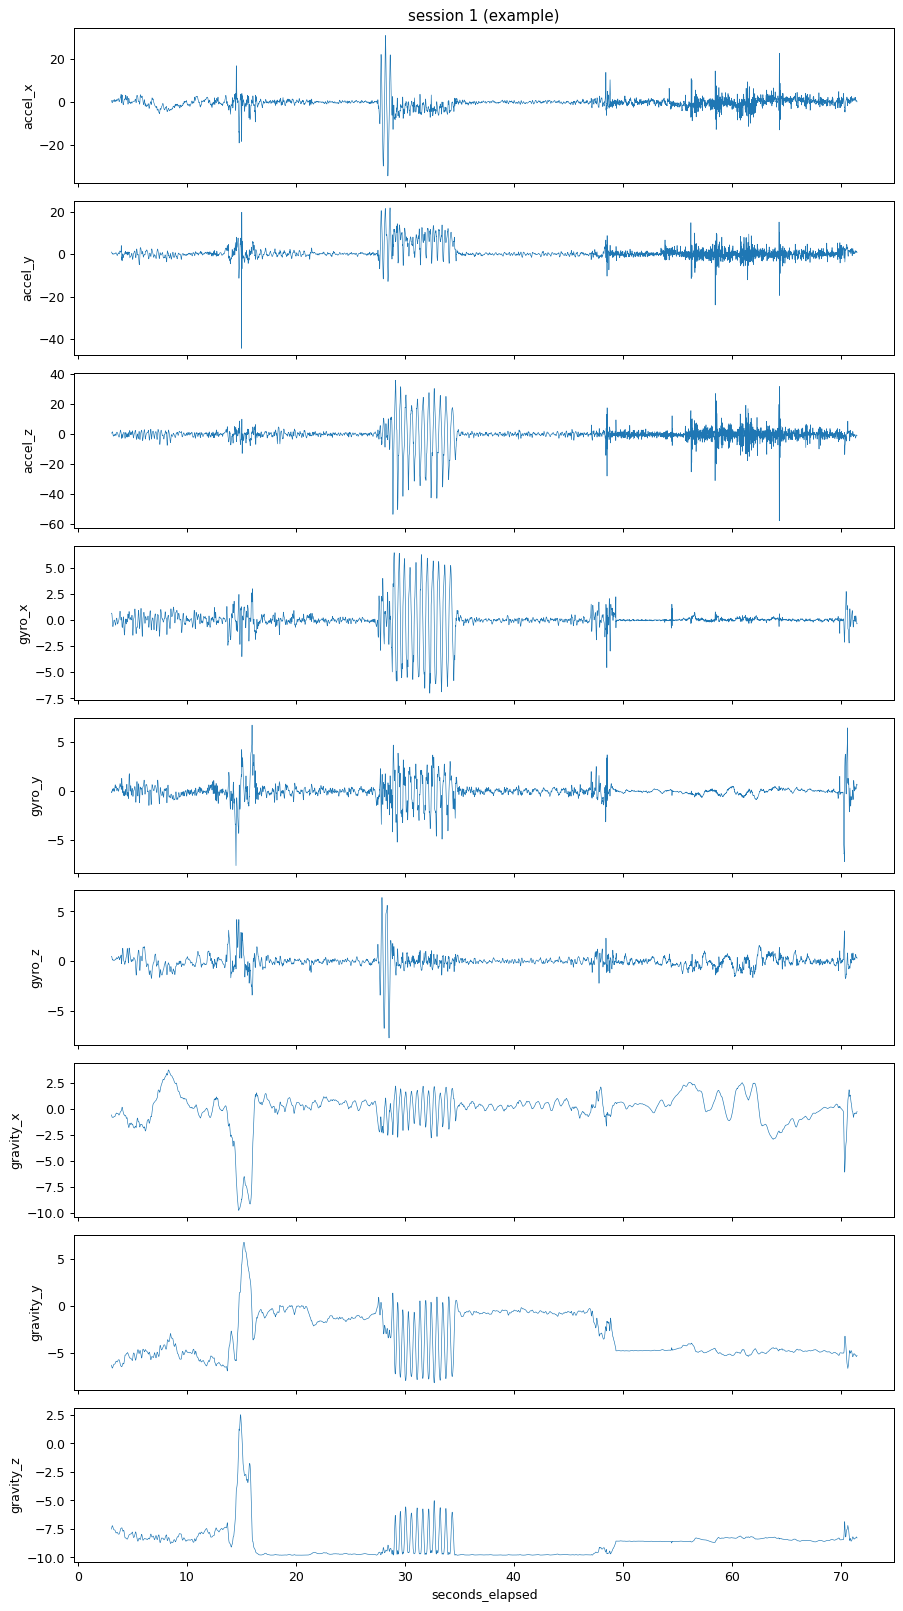

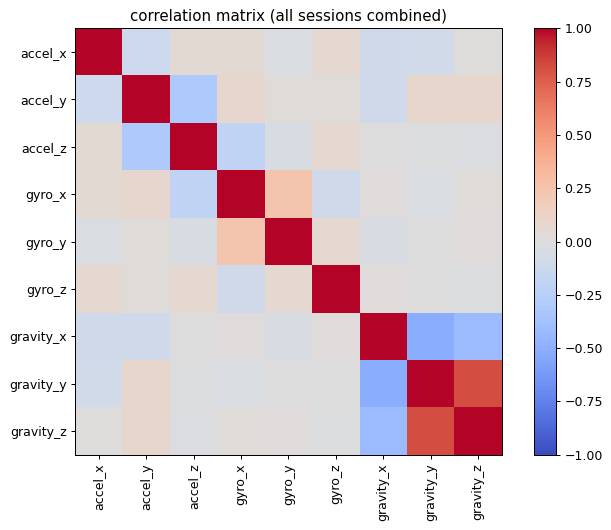

In [29]:
eda(df_filtered)

        accel_x_filt   accel_y_filt   accel_z_filt    gyro_x_filt    gyro_y_filt    gyro_z_filt  gravity_x_filt  gravity_y_filt  gravity_z_filt
count  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000  601264.000000   601264.000000    6.012640e+05    6.012640e+05
mean       -0.000045      -0.000043       0.000003       0.000013       0.000012       0.000007       -0.000002   -2.140917e-07   -2.981976e-07
std         0.949422       1.523732       2.580510       0.332313       0.215367       0.105150        0.022339    3.947898e-02    4.063018e-02
min       -43.396049     -54.115738     -88.000087     -10.101329      -9.741306      -3.137484       -1.252839   -1.217241e+00   -9.328136e-01
25%        -0.387136      -0.434708      -0.652020      -0.044920      -0.033233      -0.032167       -0.003324   -5.023301e-03   -2.955955e-03
50%         0.000554      -0.003571       0.002539       0.000075       0.000002      -0.000017       -0.000007    2.741072e-06    1.879

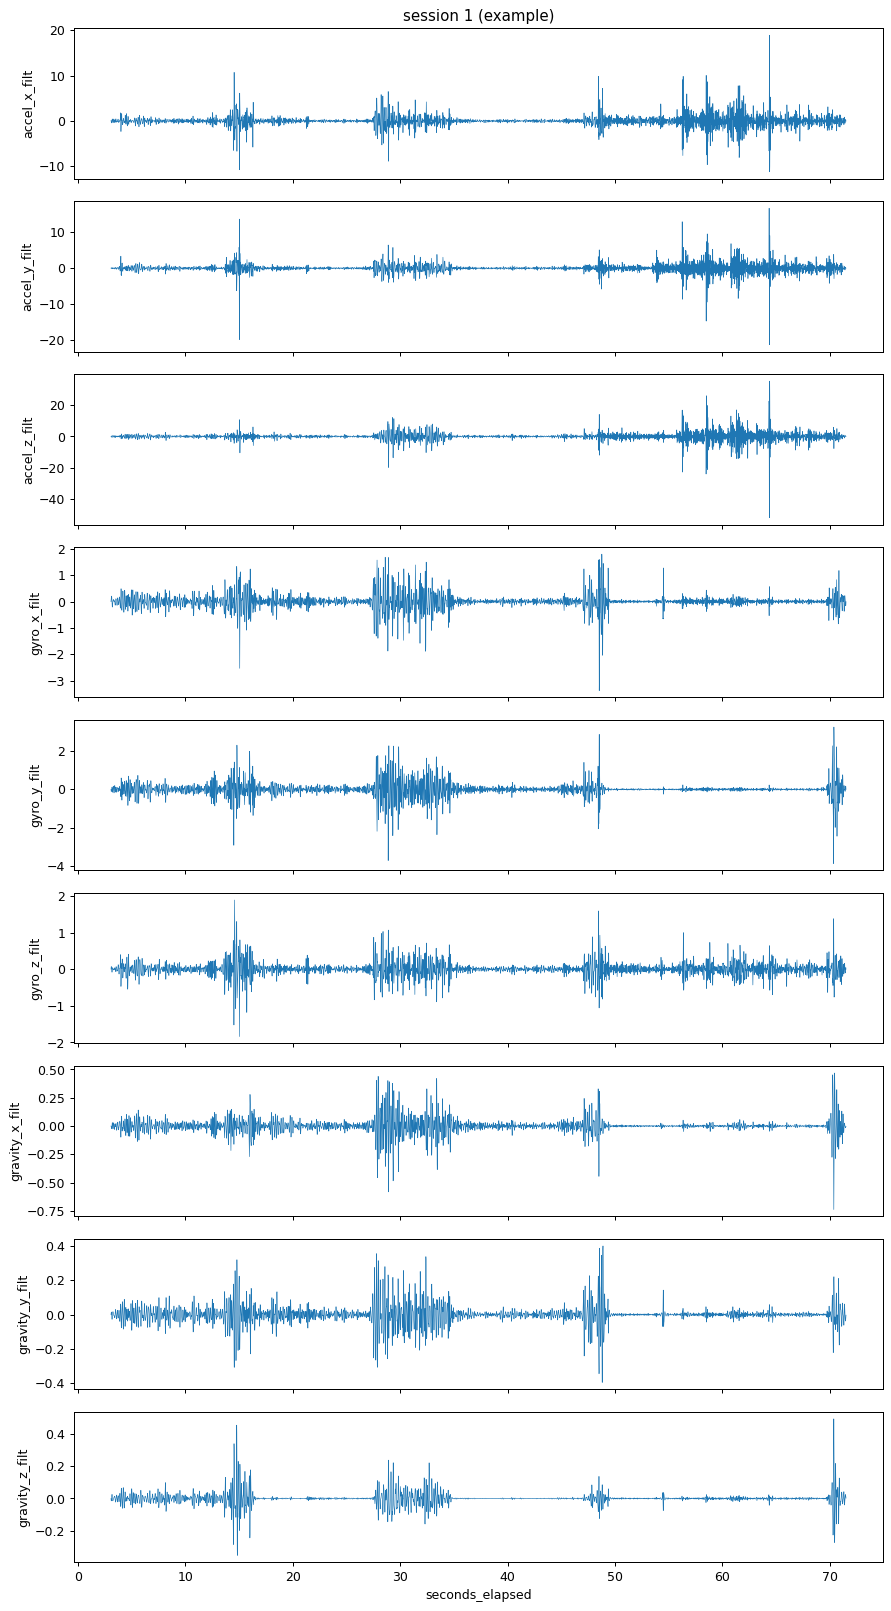

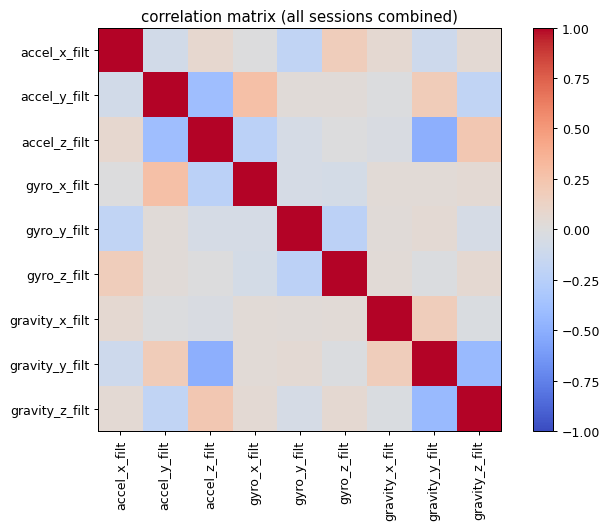

In [30]:
eda(df_filtered, columns=[f"{c}_filt" for c in ALL_SENSOR_COLS])

Example flow as written at the end of this part of `GMA_lib.py` (reproduced by the cells above):
```python
# ------------------------------------------------------------------
# Example flow, continuing straight from build_session_dataset()
# ------------------------------------------------------------------
# dataset_df = build_session_dataset(input_path=DATASET_PATH, save_csv=True)
# df_trimmed  = trim_dataframe(dataset_df, trim_start_sec=3.0, trim_end_sec=3.0, fs=FS)
# df_clean    = handle_missing_values(df_trimmed)
# df_filtered = apply_bandpass_filter(df_clean)
# n_windows, windowed_df = windowing(df_filtered, window_length=1.0, overlap_percentage=80, fs=FS)
# eda(df_filtered)
```

---
# Step 3 — Feature extraction & engineering
**In:** windowed dataframe  **Out:** feature dataframe (1 row per window) → PCA dataframe

Feature count is tracked through the step:
1. **Before engineering** – the 9 raw sensor axes (+ their 9 filtered versions) per sample.
2. **After extraction** – per-window statistics on 3 derived signals + FFT features.
3. **After correlation filter** – redundant (|r| > 0.90) features removed.
4. **After PCA** – principal components explaining 95 % of the variance.

### `extract_features(windowed_df, fs=FS)`

**1. Orientation-invariant signals** (the phone can be mounted in any orientation, so single axes are not comparable across rides):
- `accel_mag` = ‖filtered accel‖ = √(x²+y²+z²)
- `gyro_mag` = ‖filtered gyro‖
- `accel_vert` = **re-orientation to the vertical (gravity) axis**: projection of the filtered acceleration onto the unit
  gravity vector, `(a · g) / ‖g‖`. This is the up–down vibration a bump produces, whatever the phone orientation.

**2. Time-domain features** per window for each of the 3 signals (8 × 3 = 24):
`mean, std, min, max, rms, ptp (max−min), kurtosis, skew`.

**3. Frequency-domain features** on `accel_vert` (2):
- `accel_vert_dom_freq` – frequency of the largest FFT peak.
- `accel_vert_vibr_energy` – spectral energy in the 5–30 Hz band.

**Returns** one row per window: `window_id`, `session` + **26 features**.

In [31]:
def extract_features(windowed_df: pd.DataFrame, fs: float = FS) -> pd.DataFrame:
    """
    in: dataframe (windowed sensor data), sampling rate (fs)
    out: dataframe with extracted time-domain and frequency-domain (FFT) features,
         retaining 'window_id' and 'session' columns
    """
    print("\n--- 6. Feature Extraction (5ARE0 Course Pipeline) ---")

    # 1. Compute magnitudes and vertical acceleration (orientation-invariant)
    accel_cols = ["accel_x_filt", "accel_y_filt", "accel_z_filt"]
    gyro_cols = ["gyro_x_filt", "gyro_y_filt", "gyro_z_filt"]
    grav_cols = ["gravity_x", "gravity_y", "gravity_z"]

    windowed_df = windowed_df.copy()
    windowed_df["accel_mag"] = np.sqrt((windowed_df[accel_cols] ** 2).sum(axis=1))
    windowed_df["gyro_mag"] = np.sqrt((windowed_df[gyro_cols] ** 2).sum(axis=1))

    # Pure vertical component: projection onto gravity vector
    dot_p = (
        windowed_df["accel_x_filt"] * windowed_df["gravity_x"]
        + windowed_df["accel_y_filt"] * windowed_df["gravity_y"]
        + windowed_df["accel_z_filt"] * windowed_df["gravity_z"]
    )
    grav_mag = np.sqrt((windowed_df[grav_cols] ** 2).sum(axis=1))
    windowed_df["accel_vert"] = dot_p / np.where(grav_mag == 0, 1.0, grav_mag)

    # 2. Vectorized feature extraction per window_id
    signals = ["accel_mag", "gyro_mag", "accel_vert"]
    grouped = windowed_df.groupby("window_id", sort=True)

    feature_dict = {
        "window_id": grouped["window_id"].first(),
        "session": grouped["session"].first(),
    }

    # Time-Domain features
    for s in signals:
        feature_dict[f"{s}_mean"] = grouped[s].mean()
        feature_dict[f"{s}_std"] = grouped[s].std()
        feature_dict[f"{s}_min"] = grouped[s].min()
        feature_dict[f"{s}_max"] = grouped[s].max()
        feature_dict[f"{s}_rms"] = np.sqrt(grouped[s].apply(lambda x: np.mean(x**2)))
        feature_dict[f"{s}_ptp"] = feature_dict[f"{s}_max"] - feature_dict[f"{s}_min"]
        feature_dict[f"{s}_kurtosis"] = grouped[s].apply(lambda x: stats.kurtosis(x))
        feature_dict[f"{s}_skew"] = grouped[s].apply(lambda x: stats.skew(x))

    # 3. Frequency-Domain (FFT) features on accel_vert
    def extract_fft_features(series):
        x = series.values
        n_samples = len(x)
        if n_samples < 2:
            return pd.Series([0.0, 0.0], index=["dom_freq", "vibr_energy"])

        x_centered = x - np.mean(x)
        yf = np.abs(rfft(x_centered)) * (2.0 / n_samples)
        xf = rfftfreq(n_samples, 1.0 / fs)

        dom_freq = xf[np.argmax(yf)] if len(yf) > 0 else 0.0
        mask = (xf >= 5.0) & (xf <= 30.0)
        vibr_energy = np.sum(yf[mask] ** 2) if np.any(mask) else 0.0

        return pd.Series([dom_freq, vibr_energy], index=["dom_freq", "vibr_energy"])

    fft_feats = grouped["accel_vert"].apply(extract_fft_features).unstack()
    feature_dict["accel_vert_dom_freq"] = fft_feats["dom_freq"]
    feature_dict["accel_vert_vibr_energy"] = fft_feats["vibr_energy"]

    x_all = pd.DataFrame(feature_dict).reset_index(drop=True)
    print(f"Extracted {x_all.shape[0]} windows with {x_all.shape[1] - 2} features each.")
    print(x_all.head())

    return x_all

In [32]:
n_raw_axes = len(ALL_SENSOR_COLS)
n_filt_axes = len([c for c in windowed_df.columns if c.endswith("_filt")])
print(f"Features BEFORE engineering (per sample): {n_raw_axes} raw axes + {n_filt_axes} filtered axes = {n_raw_axes + n_filt_axes}")

x_all = extract_features(windowed_df, fs=FS)
n_extracted = x_all.shape[1] - 2
print(f"\nFeatures AFTER extraction (per window): {n_extracted}")

Features BEFORE engineering (per sample): 9 raw axes + 9 filtered axes = 18

--- 6. Feature Extraction (5ARE0 Course Pipeline) ---
Extracted 23956 windows with 26 features each.
   window_id  session  accel_mag_mean  accel_mag_std  accel_mag_min  accel_mag_max  accel_mag_rms  accel_mag_ptp  accel_mag_kurtosis  accel_mag_skew  gyro_mag_mean  gyro_mag_std  gyro_mag_min  \
0          0        1        0.668314       0.726059       0.005029       4.044641       0.984141       4.039612            7.079309        2.700845       0.184372      0.132878      0.003454   
1          1        1        0.788537       0.753077       0.041530       4.044641       1.087770       4.003111            4.407654        2.095681       0.238710      0.161794      0.049985   
2          2        1        0.961880       0.766583       0.041530       4.044641       1.227594       4.003111            2.433479        1.493869       0.296008      0.167802      0.059995   
3          3        1        1.197687     

In [33]:
x_all.describe().T

,count,mean,std,min,25%,50%,75%,max
window_id,23956.0,11977.500000,6915.645860,0.000000,5988.750000,11977.500000,17966.250000,23955.000000
session,23956.0,12.479671,8.699129,1.000000,3.000000,13.000000,19.000000,28.000000
accel_mag_mean,23956.0,1.865965,1.763954,0.022877,0.989224,1.350175,2.054199,25.684117
accel_mag_std,23956.0,1.199497,1.371137,0.010179,0.513246,0.752742,1.281378,17.922616
accel_mag_min,23956.0,0.259615,0.243129,0.001552,0.118804,0.202860,0.315212,5.005341
accel_mag_max,23956.0,6.297423,7.378414,0.047458,2.607011,3.890077,6.750449,94.637223
accel_mag_rms,23956.0,2.234503,2.210424,0.025424,1.123085,1.555192,2.439135,28.414743
accel_mag_ptp,23956.0,6.037808,7.235008,0.041565,2.440924,3.676981,6.441301,94.547839
accel_mag_kurtosis,23956.0,1.875913,3.160715,-1.158912,0.036397,0.843469,2.405568,53.007783
accel_mag_skew,23956.0,1.159822,0.691670,-0.362457,0.700850,0.997219,1.428937,6.929701


### `select_features_and_pca(x_all, variance_threshold=0.95, output_path=None, save_csv=True)`

**1. Clean-up** – replaces ±inf with NaN and fills NaNs with the column mean.

**2. Correlation filter** – computes the absolute Pearson correlation matrix; for every pair with |r| > 0.90 the later
feature is dropped (e.g. `rms` is almost identical to `mean` for a magnitude signal). Prints the counts and the dropped names.

**3. Standardise + PCA** – z-scores the remaining features (`StandardScaler`) and keeps as many principal components as needed
to explain `variance_threshold` (95 %) of the variance. Plots the cumulative explained variance (scree plot).
*The plot title says "Session 4", but the PCA is fitted on all windows from all sessions.*

**4. Saves** `extracted_features.csv` and `X_selected_pca.csv` to `output_path`.

**Returns** a dataframe `PC_1 … PC_k` + `window_id` + `session`.

In [34]:
def select_features_and_pca(x_all: pd.DataFrame, variance_threshold: float = 0.95,
                            output_path=None, save_csv: bool = True) -> pd.DataFrame:
    """
    in: dataframe (extracted features), variance_threshold (float), optional output_path,
        save_csv flag
    out: dataframe with principal components (PC_1, PC_2, ...) explaining the target
         cumulative variance, plus 'window_id' and 'session' columns
    """
    print("\n--- 7. Feature Selection: Correlation & PCA ---")
    output_path = Path(output_path) if output_path else Path("OutputData")

    feature_cols = [c for c in x_all.columns if c not in ["window_id", "session"]]
    x = x_all[feature_cols].copy()
    x = x.replace([np.inf, -np.inf], np.nan).fillna(x.mean())

    # Step 1: Multicollinearity filtering (Pearson correlation > 0.90)
    corr_matrix = x.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    cols_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]

    x_uncorr = x.drop(columns=cols_to_drop)
    print(f"Original Features: {x.shape[1]}")
    print(f"Features after correlation filter (r < 0.90): {x_uncorr.shape[1]}")
    print(f"Dropped as redundant: {cols_to_drop}")

    # Step 2: Standardization & PCA
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_uncorr)

    pca = PCA(n_components=variance_threshold, random_state=42)
    x_pca = pca.fit_transform(x_scaled)

    print(f"\n[PCA] Dimensions reduced to {pca.n_components_} principal components.")
    print(f"Total Explained Variance: {np.sum(pca.explained_variance_ratio_):.2%}")

    # Scree Plot
    plt.figure(figsize=(8, 4))
    plt.plot(
        range(1, pca.n_components_ + 1),
        np.cumsum(pca.explained_variance_ratio_),
        marker="o",
        color="navy",
    )
    plt.axhline(
        y=variance_threshold,
        color="r",
        linestyle="--",
        label=f"{int(variance_threshold * 100)}% Explained Variance",
    )
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Variance")
    plt.title("PCA Explained Variance Ratio (Session 4)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    df_pca = pd.DataFrame(x_pca, columns=[f"PC_{i+1}" for i in range(pca.n_components_)])
    df_pca["window_id"] = x_all["window_id"]
    df_pca["session"] = x_all["session"]

    if save_csv:
        output_path.mkdir(parents=True, exist_ok=True)
        x_all.to_csv(output_path / "extracted_features.csv", index=False)
        print(f"Saved: {output_path / 'extracted_features.csv'}")

        df_pca.to_csv(output_path / "X_selected_pca.csv", index=False)
        print(f"Saved: {output_path / 'X_selected_pca.csv'}")

    return df_pca


--- 7. Feature Selection: Correlation & PCA ---
Original Features: 26
Features after correlation filter (r < 0.90): 11
Dropped as redundant: ['accel_mag_std', 'accel_mag_max', 'accel_mag_rms', 'accel_mag_ptp', 'accel_mag_skew', 'gyro_mag_std', 'gyro_mag_max', 'gyro_mag_rms', 'gyro_mag_ptp', 'gyro_mag_skew', 'accel_vert_std', 'accel_vert_min', 'accel_vert_max', 'accel_vert_rms', 'accel_vert_ptp']

[PCA] Dimensions reduced to 8 principal components.
Total Explained Variance: 96.03%


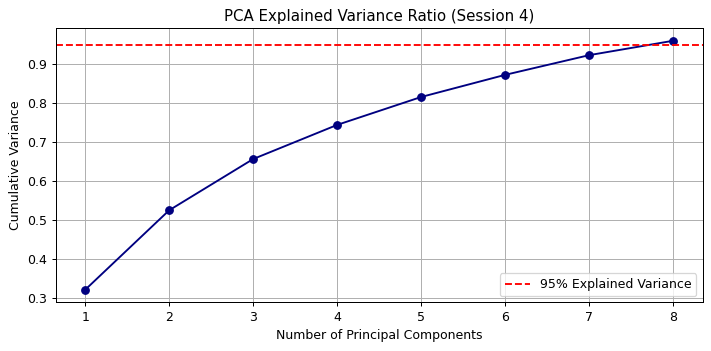

Saved: OutputData/extracted_features.csv
Saved: OutputData/X_selected_pca.csv


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,window_id,session
0,0.368764,4.989984,-1.083242,1.229163,0.174814,-0.223527,0.692416,-0.152114,0,1
1,0.023827,1.968402,-1.782764,0.421920,-0.394413,0.759355,-0.734515,-0.338653,1,1
2,-0.305874,0.037777,-1.855794,0.055731,0.082090,0.586351,-0.789834,-0.363404,2,1
3,0.000189,-0.253608,-1.551389,-0.185979,-0.003699,0.790872,-0.305527,-0.522942,3,1
4,-0.135623,-1.352862,-2.411610,-1.375264,0.147057,0.842247,0.252276,-0.879567,4,1


In [35]:
df_pca = select_features_and_pca(x_all, variance_threshold=0.95, output_path=OUTPUT_PATH, save_csv=True)
df_pca.head()

### Feature count summary

In [36]:
feature_cols = [c for c in x_all.columns if c not in ["window_id", "session"]]
corr = x_all[feature_cols].replace([np.inf, -np.inf], np.nan).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
n_after_corr = len(feature_cols) - sum(any(upper[c] > 0.90) for c in upper.columns)
n_pcs = len([c for c in df_pca.columns if c.startswith("PC_")])

feature_counts = pd.DataFrame({
    "stage": ["raw sensor axes (per sample)", "raw + filtered axes (per sample)",
              "extracted features (per window)", "after correlation filter", "after PCA (95% var.)"],
    "n_features": [n_raw_axes, n_raw_axes + n_filt_axes, n_extracted, n_after_corr, n_pcs],
})
feature_counts

,stage,n_features
0,raw sensor axes (per sample),9
1,raw + filtered axes (per sample),18
2,extracted features (per window),26
3,after correlation filter,11
4,after PCA (95% var.),8


Example flow as written at the end of `GMA_lib.py` (reproduced by the cells above):
```python
# ------------------------------------------------------------------
# Example flow, continuing straight from windowing()
# ------------------------------------------------------------------
# x_all  = extract_features(windowed_df, fs=FS)
# df_pca = select_features_and_pca(x_all, variance_threshold=0.95, output_path=OUTPUT_PATH, save_csv=True)
```

choose manually the sessions, see visually, apply treshold and label them 

--unsupervised: these will be used to produce psuedo labels as well as meets the project requirement of having 4 unsupervised models. the labels and data generated here(from the best performing model) can be used in all supervised models. 
1. gk clustering
2. kmeans clustering
3. gausian mm
4. som
